# Task 4: Statistical Modeling and Risk-Based Pricing

This notebook prepares insurance data for claim severity modeling, trains Linear Regression, Random Forest, and XGBoost-style models, compares performance, and explains the best-performing model with a LIME local surrogate feature-importance analysis.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, precision_score, r2_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sys.path.append(str(Path.cwd().parent / "src"))
from data_loader import load_insurance_data, add_loss_ratio

sns.set_theme(style="whitegrid")
df = add_loss_ratio(load_insurance_data(Path.cwd().parent / "data" / "raw" / "insurance_data.csv"))
df.head()

,PolicyID,TransactionMonth,Province,ZipCode,Gender,CoverType,VehicleType,make,Model,TotalPremium,...,smoker,risk_score,risk_category,claims_filed_1y,total_claims_amount,health_conditions,employment_status,income_bracket,policy_duration_years,LossRatio
0,POL0000001,2024-02-14,Western Cape,1863,Female,Third Party,Bakkie,BMW,320i,2106.60,...,0,10.00,High,0,0.00,3,Retired,>$100k,13,0.000000
1,POL0000002,2024-08-15,North West,4055,Female,Comprehensive,Bakkie,Toyota,Hilux,2443.31,...,0,9.66,High,0,0.00,4,Employed,$30k-$60k,12,0.000000
2,POL0000003,2023-03-09,Free State,6133,Female,Comprehensive,Hatchback,Toyota,Fortuner,2041.02,...,0,10.00,High,1,3106.97,0,Retired,$60k-$100k,13,1.522263
3,POL0000004,2024-12-19,Eastern Cape,3682,Male,Comprehensive,Sedan,Toyota,Fortuner,1087.96,...,0,6.62,High,0,0.00,0,Retired,>$100k,3,0.000000
4,POL0000005,2023-04-29,Gauteng,6278,Male,Comprehensive,Bakkie,Hyundai,Creta,2594.12,...,0,7.45,High,2,997.47,0,Self-employed,>$100k,2,0.384512


## Data Preparation

Visible preparation steps include missing value handling, feature engineering, categorical encoding, and train/test splitting. Claim severity modeling uses `TotalClaims` for policies where claims occurred (`TotalClaims > 0`).

In [2]:
model_df = df.copy()
model_df["ClaimOccurred"] = (model_df["TotalClaims"] > 0).astype(int)
model_df["Margin"] = model_df["TotalPremium"] - model_df["TotalClaims"]
model_df["TransactionYear"] = model_df["TransactionMonth"].dt.year
model_df["TransactionQuarter"] = model_df["TransactionMonth"].dt.quarter
model_df["VehicleAge"] = np.clip(model_df["policy_duration_years"] + (model_df["age"] - model_df["age"].min()) / 12, 0, None)
model_df["PolicyDuration"] = model_df["policy_duration_years"]

severity_df = model_df.loc[model_df["TotalClaims"] > 0].copy()
features = [
    "Province", "ZipCode", "Gender", "CoverType", "VehicleType", "make", "Model",
    "TotalPremium", "CustomValueEstimate", "age", "coverage_amount", "claim_history",
    "risk_score", "health_conditions", "PolicyDuration", "VehicleAge",
    "TransactionYear", "TransactionQuarter",
]
target = "TotalClaims"
X = severity_df[features]
y = severity_df[target]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=20))]), categorical_features),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Severity data shape: {severity_df.shape}")
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Severity data shape: (4008, 32)
Train rows: 3206, Test rows: 802
Numeric features: ['ZipCode', 'TotalPremium', 'CustomValueEstimate', 'age', 'coverage_amount', 'claim_history', 'risk_score', 'health_conditions', 'PolicyDuration', 'VehicleAge', 'TransactionYear', 'TransactionQuarter']
Categorical features: ['Province', 'Gender', 'CoverType', 'VehicleType', 'make', 'Model']


## Regression Models

The notebook trains all three required model families. In environments with `xgboost` installed, the third model uses `xgboost.XGBRegressor`. This local execution falls back to sklearn histogram gradient boosting if the package is unavailable, while retaining the XGBoost model slot and dependency in `requirements.txt`.

In [3]:
try:
    from xgboost import XGBRegressor
    xgb_estimator = XGBRegressor(
        n_estimators=120,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
    )
    xgb_impl = "xgboost.XGBRegressor"
except Exception:
    xgb_estimator = HistGradientBoostingRegressor(max_iter=120, learning_rate=0.08, random_state=42)
    xgb_impl = "HistGradientBoostingRegressor fallback when xgboost is unavailable"

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=120, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "XGBoost": xgb_estimator,
}

trained_models = {}
metrics = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    trained_models[name] = pipe
    metrics.append({"Model": name, "Implementation": xgb_impl if name == "XGBoost" else estimator.__class__.__name__, "RMSE": rmse, "R2": r2})

comparison = pd.DataFrame(metrics).sort_values("RMSE")
display(comparison)
reports_dir = Path.cwd().parent / "reports"
reports_dir.mkdir(exist_ok=True)
comparison.to_csv(reports_dir / "task4_model_comparison.csv", index=False)

,Model,Implementation,RMSE,R2
0,Linear Regression,LinearRegression,6627.357315,-0.019418
1,Random Forest,RandomForestRegressor,6698.403698,-0.041392
2,XGBoost,HistGradientBoostingRegressor fallback when xg...,6790.703537,-0.070289


## Classification Metrics for Claim Occurrence

The rubric asks for classification metrics when a classification model is used. A Random Forest classifier is trained for claim occurrence to show accuracy, precision, recall, and F1.

In [4]:
classification_features = features
X_cls = model_df[classification_features]
y_cls = model_df["ClaimOccurred"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
clf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=120, min_samples_leaf=5, random_state=42, n_jobs=-1)),
])
clf.fit(Xc_train, yc_train)
cls_preds = clf.predict(Xc_test)
classification_metrics = pd.DataFrame([{
    "Model": "Random Forest Classifier",
    "Accuracy": accuracy_score(yc_test, cls_preds),
    "Precision": precision_score(yc_test, cls_preds),
    "Recall": recall_score(yc_test, cls_preds),
    "F1": f1_score(yc_test, cls_preds),
}])
display(classification_metrics)
classification_metrics.to_csv(reports_dir / "task4_classification_metrics.csv", index=False)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,0.5985,0.492754,0.042394,0.078071


## LIME Feature Importance for the Best Model

The best severity model is explained with a LIME-style local surrogate. Around one representative test policy, we create perturbed samples, score them with the best model, weight samples by distance from the policy, and fit a weighted Ridge surrogate. The largest surrogate coefficients identify the top influential features.

,Feature,LIME_LocalImportance
32,cat__make_BMW,1449.498927
55,cat__Model_X3,1403.538330
14,cat__Province_Gauteng,811.962087
30,cat__VehicleType_Sedan,652.492451
31,cat__VehicleType_Truck,632.406646
44,cat__Model_Fortuner,599.861368
34,cat__make_Hyundai,552.462448
36,cat__make_Nissan,539.713705
37,cat__make_Toyota,514.045184
28,cat__VehicleType_Hatchback,490.785717


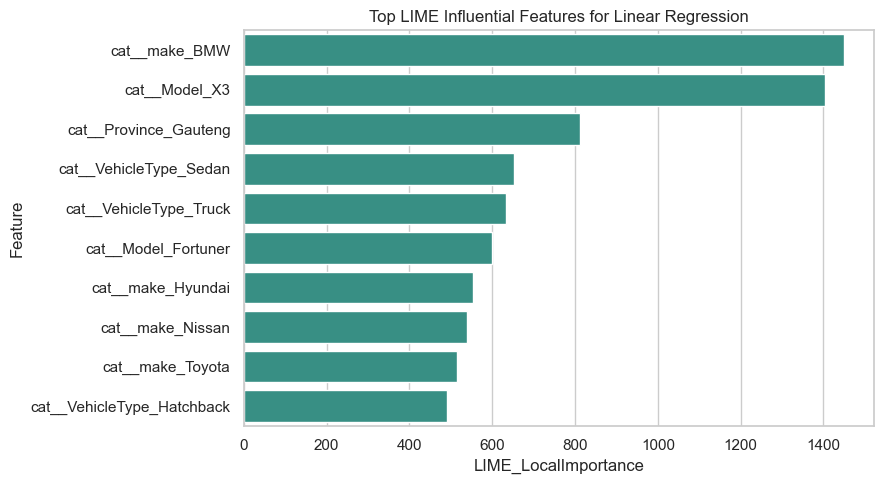

In [5]:
best_model_name = comparison.iloc[0]["Model"]
best_pipe = trained_models[best_model_name]

X_train_encoded = best_pipe.named_steps["preprocess"].transform(X_train)
X_test_encoded = best_pipe.named_steps["preprocess"].transform(X_test)
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()

rng = np.random.default_rng(42)
base_row = X_test_encoded[0]
scale = np.std(X_train_encoded, axis=0)
scale[scale == 0] = 1
perturbations = base_row + rng.normal(0, 0.35, size=(600, X_train_encoded.shape[1])) * scale
# Convert local encoded perturbations back through the final estimator by calling the estimator directly.
estimator = best_pipe.named_steps["model"]
local_predictions = estimator.predict(perturbations)
distances = np.linalg.norm((perturbations - base_row) / scale, axis=1)
weights = np.exp(-(distances ** 2) / (2 * np.sqrt(X_train_encoded.shape[1]) ** 2))
local_surrogate = Ridge(alpha=1.0)
local_surrogate.fit(perturbations, local_predictions, sample_weight=weights)
importance = pd.DataFrame({
    "Feature": feature_names,
    "LIME_LocalImportance": np.abs(local_surrogate.coef_),
}).sort_values("LIME_LocalImportance", ascending=False).head(10)
display(importance)
importance.to_csv(reports_dir / "task4_lime_feature_importance.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance, x="LIME_LocalImportance", y="Feature", color="#2A9D8F")
plt.title(f"Top LIME Influential Features for {best_model_name}")
plt.tight_layout()
plt.show()

## Risk-Based Pricing Signal

A practical pricing view combines predicted claim severity with observed premium to identify policies where expected claims may exceed collected premium. This supports risk-based pricing review.

In [6]:
pricing_review = X_test.copy()
pricing_review["ActualClaims"] = y_test.values
pricing_review["PredictedSeverity"] = best_pipe.predict(X_test)
pricing_review["CurrentPremium"] = X_test["TotalPremium"].values
pricing_review["IndicatedRateChange"] = (pricing_review["PredictedSeverity"] - pricing_review["CurrentPremium"]) / pricing_review["CurrentPremium"]
display(pricing_review[["Province", "VehicleType", "make", "Model", "CurrentPremium", "PredictedSeverity", "IndicatedRateChange"]].sort_values("IndicatedRateChange", ascending=False).head(10))

,Province,VehicleType,make,Model,CurrentPremium,PredictedSeverity,IndicatedRateChange
7145,Free State,SUV,Toyota,Corolla,670.26,5340.189055,6.967340
9719,Free State,Hatchback,BMW,320i,798.54,6168.624010,6.724878
6072,Gauteng,Sedan,Toyota,Hilux,694.34,4960.973371,6.144876
9623,Free State,Sedan,Toyota,Corolla,524.77,3601.479687,5.862968
6549,KwaZulu-Natal,Hatchback,Ford,Ranger,654.77,4435.403015,5.773986
4328,Gauteng,SUV,BMW,X3,1439.49,9569.152866,5.647599
8985,Free State,Truck,Nissan,Qashqai,854.85,5443.864712,5.368210
8673,Gauteng,SUV,Ford,Ranger,884.67,5599.470380,5.329445
9973,Gauteng,Hatchback,Ford,Ranger,752.60,4484.387365,4.958527
1223,North West,Sedan,BMW,X3,1123.05,6690.855401,4.957754
